In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random
import csv
import json
from tqdm import tqdm
from joblib import Parallel, delayed

In [4]:
class CNNChromagram(nn.Module):
    def __init__(self, input_time=861):
        super(CNNChromagram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding='same', dilation=(1, 2))
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same', dilation=(1, 2))
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding='same', dilation=(1, 2))

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))

        fc_input_size = 64 * (25 // 4)

        self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc2 = nn.Linear(64, 4)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, channels, freq_bins, time_steps = x.shape

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [250]:
class ChromaDataset(Dataset):
    def __init__(self, audio_dir, label_json, num_classes=4, sr=16000, window_size=20, hop_length=512, target_bins=25):
        super().__init__()
        self.sr = sr
        self.target_bins = target_bins
        self.audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav') or f.endswith('.mp3')]
        self.loaded_audio = self.get_audio()
        self.loaded_chromas = self.get_chroma()

        self.df = self.get_df(label_json)
        self.window_size = window_size
        self.window_frames = window_size*sr//hop_length
        self.segments = self.get_segments()

        self.num_classes = num_classes
        self.label_map = {"Unknown":0, "청조":0, "세면조":0, "우조":1, "계면조":2, "아니리":3}
        self.hop_size = hop_length
        self.labels = self.get_labels()

    def get_audio(self):
        loaded_audio = {}
        for filename in tqdm(self.audio_files, desc='Load Audio'):
            y, _ = librosa.load(os.path.join(audio_dir, filename), sr=self.sr)
            loaded_audio[filename] = y
        return loaded_audio

    def get_chroma(self):
        '''
        loaded_audio를 로드하여 file별로 chromagram 생성 후 target bins에 맞추어 expand하여 반환
        '''
        chroma_dict = {}
        for filename, audio_key_value in zip(tqdm(self.audio_files, desc="Load Chroma"), self.loaded_audio.items()):
            chroma = librosa.feature.chroma_stft(y=audio_key_value[1], sr=self.sr)
            repeat = self.target_bins // chroma.shape[0] + 1
            expanded_chroma = np.tile(chroma, (repeat, 1))
            chroma_dict[filename]=expanded_chroma[:self.target_bins, :]
        return chroma_dict

# default dict
    def get_df(self, label_json):
        with open(label_json, "r", encoding="utf-8") as file: label_data = json.load(file)
        df = pd.DataFrame(columns=['filename', 'start', 'end', 'duration', 'label'])
        row = 0
        song_segments = {}
        for song in label_data:
            filename = song['file_upload'][:-3]+'wav'
            if filename not in song_segments: song_segments[filename] = []
            
            for val in song['annotations'][0]["result"]:
                start = val['value']['start']
                end = val['value']['end']
                label = val['value']['labels'][0]
                song_segments[filename].append((start, end, label))

        for filename, segments in song_segments.items():
            prev_end = None
            segments.sort(key=lambda x: x[0])
            for start, end, label in segments:
                if prev_end is not None and int(prev_end) != int(start):
                    gap_start, gap_end = prev_end+1e-6, start-1e-6
                    gap_duration = gap_end - gap_start

                    if gap_duration < 1: continue
                    df.loc[row] = [filename, gap_start, gap_end, gap_duration, "Unknown"]
                    row += 1
                
                duration = end - start
                df.loc[row] = [filename, start, end, duration, label]
                prev_end = end
                row += 1
        return df

# 0에서 offset만 랜덤하게
    def get_segments(self):
        """
            audio 길이에 비례하여 20초 단위로 random sampling
            총 segment의 수는 audio length // 20sec 
            random sampled start_times를 기준으로 20sec에 해당하는 chroma의 time frame을 crop하여 segments에 추가 후 return
        """
        segments = []
        for filename in self.audio_files:
            duration = librosa.get_duration(y=self.loaded_audio[filename], sr=self.sr)
            num_segments = int(duration // self.window_size)

            start_times = np.random.uniform(0, max(1, duration - self.window_size), num_segments)
            num_frames = self.loaded_chromas[filename].shape[1]

            for start_time in start_times:
                start_frame = int(num_frames * start_time / duration)
                end_frame = int(start_frame + self.window_frames)
                segments.append((filename, start_frame, end_frame))

        return segments
 # sec만 정ㅎ래서   
    def get_labels(self):
        """
        segments: [filename, start_frame, end_frame]
        df: DataFrame with columns ['filename', 'start', 'end', 'duration', 'label']
        returns: Dictionary mapping (filename, start_frame, end_frame) to label tensor [self.window_frames, num_classes]
        """
        labels_dict = {}

        for segment in dset.segments:
            filename, start_frame, end_frame = segment
            duration = librosa.get_duration(y=dset.loaded_audio[filename], sr=dset.sr)    

            segment_labels = np.zeros((dset.window_frames, self.num_classes))
            segment_labels[:, dset.label_map["Unknown"]] = 1
            
            file_df = dset.df[dset.df['filename'] == filename]
            
            if not file_df.empty:
                num_frames = dset.loaded_chromas[filename].shape[1]
                
                for _, row in file_df.iterrows():
                    label_start_frame = (row['start'] / self.hop_size) * self.sr
                    label_end_frame = (row['end'] / self.hop_size) * self.sr
                    
                    overlap_start = int(max(start_frame, label_start_frame))
                    overlap_end = int(min(end_frame, label_end_frame))

                    if overlap_start < overlap_end:
                        segment_start_idx = int(overlap_start - start_frame)
                        segment_end_idx = int(overlap_end - start_frame)

                        segment_labels[segment_start_idx:segment_end_idx, self.label_map["Unknown"]] = 0
                        label_idx = self.label_map.get(row['label'], self.label_map["Unknown"])
                        segment_labels[segment_start_idx:segment_end_idx, label_idx] = 1

            labels_dict[segment] = torch.tensor(segment_labels, dtype=torch.float32)
        
        return labels_dict

# 1. 오디오-label(sr,hop,)
# 2. chroma in torch

audio_dir = "/Users/jcastle/workspace/pansori/-/Pansori_2025_ISMIR/PansoriData/Audio/new"
label_json = "/Users/jcastle/workspace/pansori/-/Pansori_2025_ISMIR/PansoriData/label.json"
dset = ChromaDataset(audio_dir, label_json)

Load Chroma: 100%|██████████| 9/9 [00:04<00:00,  1.84it/s]


In [ ]:
# dset.labelsß

557.6 577.6


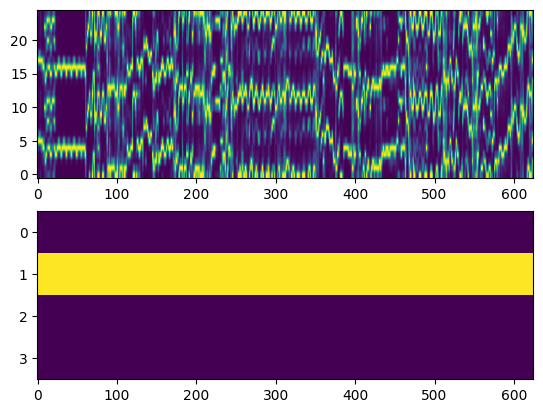

In [255]:
dset.labels[('a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav',3447,4072)]
len(dset.labels)

# plt.imshow(dset.segments[0])

f, s, e = dset.segments[0]

plt.subplot(2,1,1)
plt.imshow(dset.loaded_chromas[f][:,s:e], aspect='auto', origin='lower')
# f,s,e
plt.subplot(2,1,2)
plt.imshow(dset.labels[('a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav',3447,4072)].T, aspect='auto', interpolation='None')

s_t = s*512
e_t = e*512

import IPython.display as ipd
ipd.display(ipd.Audio(data=dset.loaded_audio[f][s_t:e_t], rate=16000))

print(s_t/16000, e_t/16000)

In [168]:
for idx, segment in enumerate(dset.segments):

    filename = segment[0]
    start_frame = segment[1]
    end_frame = segment[2]

    num_frames = dset.loaded_chromas[filename].shape[1]
    duration = librosa.get_duration(y=dset.loaded_audio[filename], sr=dset.sr)
    start_time = int(start_frame*duration/num_frames)
    end_time = int(end_frame*duration/num_frames)

    print("="*25,f"{idx}","="*25)
    print(filename)
    print(start_time, end_time)
    print(start_frame, end_frame, end_frame-start_frame)
    if end_frame-start_frame!=dset.window_frames:
        print(filename)
        break


# labels[start_frame : end_frame, mode_label] = 1

========================= 0 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
25 45
808.0 1433.0 625.0
========================= 1 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
444 464
13902.0 14527.0 625.0
========================= 2 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
430 450
13443.0 14068.0 625.0
========================= 3 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
215 235
6729.0 7354.0 625.0
========================= 4 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
538 558
16821.0 17446.0 625.0
========================= 5 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
192 212
6025.0 6650.0 625.0
========================= 6 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
89 109
2786.0 3411.0 625.0
========================= 7 =========================
a35f585a-03-박초월-수궁가_토끼_용왕_속이는_대목.wav
36 56
1154.0 1779.0 625.0
========================= 8 ====================